🗂️ Carga de librerías y dataset
Lo primero que haremos será:

Importar las librerías necesarias.

Cargar el dataset directamente desde GitHub, evitando así depender de Google Drive.

Descargar y descomprimir el archivo (que fue subido comprimido por temas de espacio) directamente en este entorno de Colab.

✅ Este procedimiento ya está automatizado en las celdas siguientes.

In [ ]:
#importaciones necesarias para trabajar
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import urllib.request
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np
from sklearn.linear_model import ElasticNet

In [ ]:
# URL directa del archivo comprimido
url = 'https://github.com/wil101/DataSetIA/raw/main/Tarifas_aplicadas_de_Gas_Natural_20250724.zip'

# Ruta local donde se guardará temporalmente
zip_path = 'Tarifas_aplicadas_de_Gas_Natural_20250724.zip'

# Descargar el archivo ZIP desde la URL
urllib.request.urlretrieve(url, zip_path)
print("Archivo descargado correctamente.")

Archivo descargado correctamente.


In [ ]:
# Carpeta de destino para la extracción
extract_dir = './data'

# Crear carpeta si no existe
os.makedirs(extract_dir, exist_ok=True)

# Extraer el contenido del archivo ZIP a la carpeta de destino
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print("Archivo descomprimido correctamente.")

Archivo descomprimido correctamente.


🔍 Exploración y análisis preliminar del dataset
Una vez importado el dataset, lo convertiremos en un DataFrame para comenzar el análisis en Colab. A partir de ahí:

Revisaremos su estructura general: número de filas, columnas y valores nulos.

Utilizaremos .describe() para obtener estadísticas básicas:

*  Media

*  Desviación estándar

* Mínimo y máximo

* Percentiles (25%, 50%, 75%)

* Conteo de valores

* Complementaremos con el cálculo de la moda si es necesario.

* Generaremos los primeros boxplots para visualizar la distribución y detectar posibles datos atípicos.

* Crearemos nuevos DataFrames filtrando los valores atípicos.

* Finalmente, tomaremos decisiones sobre limpieza o transformación de los datos con base en estos hallazgos.

In [ ]:
# Cargar el dataset desde el archivo CSV descomprimido en un DataFrame de pandas
# Se asume que el archivo CSV se llama igual que el zip sin la extensión .zip y está dentro de la carpeta de extracción.
# Ajusta la ruta si el nombre del archivo o la estructura del zip son diferentes.
df_gas_natural = pd.read_csv(os.path.join(extract_dir, 'Tarifas_aplicadas_de_Gas_Natural_20250724.csv'))

In [ ]:
# Mostrar estadísticas descriptivas de las columnas numéricas del DataFrame
df_gas_natural.describe()

,ANO,MES,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
count,165360.000000,165360.000000,1.653600e+05,165360.000000,165360.000000,165360.000000,1.653600e+05,1.653600e+05,1.653600e+05,1.653600e+05,1.653600e+05,165360.000000
mean,2016.445549,6.491570,8.534958e+09,133.489375,4670.692846,3.360414,5.743195e+05,1.840359e+05,2.811998e+04,2.128677e+03,1.931036e+03,1416.393095
std,4.579813,3.422467,4.191090e+08,155.417586,8519.143819,1.692553,1.705539e+05,1.375608e+05,2.980584e+04,1.308642e+04,1.382530e+04,1324.447965
min,2004.000000,1.000000,8.000078e+09,9.000000,484.000000,1.000000,0.000000e+00,0.000000e+00,0.000000e+00,-1.009710e+03,0.000000e+00,0.000000
25%,2014.000000,4.000000,8.040028e+09,37.000000,564.000000,2.000000,4.891250e+05,8.526300e+04,2.066000e+04,0.000000e+00,8.618191e+02,671.510000
50%,2017.000000,7.000000,8.901017e+09,103.000000,620.000000,3.000000,5.503270e+05,1.563850e+05,2.717100e+04,2.266605e+03,1.379000e+03,1390.980000
75%,2020.000000,9.000000,8.909050e+09,167.000000,2097.000000,5.000000,6.272080e+05,2.225000e+05,3.487500e+04,3.382510e+03,2.204250e+03,2009.530000
max,2023.000000,12.000000,9.010428e+09,1825.000000,37253.000000,6.000000,1.870000e+06,9.826062e+06,4.600208e+06,3.723696e+06,5.119020e+06,157525.000000


In [ ]:
# Mostrar información sobre el DataFrame, incluyendo el tipo de dato de cada columna y la cantidad de valores no nulos
df_gas_natural.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165360 entries, 0 to 165359
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ANO            165360 non-null  int64  
 1   MES            165360 non-null  int64  
 2   EMPRESA        165360 non-null  object 
 3   MUNICIPIOS     165360 non-null  object 
 4   NIT            165360 non-null  int64  
 5   ID MERCADO     165360 non-null  int64  
 6   ID_EMPRESA     165360 non-null  int64  
 7   ESTRATO        165360 non-null  int64  
 8   CONEXION       165360 non-null  float64
 9   REINSTALACION  165360 non-null  float64
 10  RECONEXION     165360 non-null  float64
 11  CARGO_FIJO     165360 non-null  float64
 12  RANGO_0        165360 non-null  float64
 13  RANGO_21       165360 non-null  float64
dtypes: float64(6), int64(6), object(2)
memory usage: 17.7+ MB


In [ ]:
# Encontrar y mostrar el valor mínimo en la columna 'ANO'
df_gas_natural['CONEXION'].min()

0.0

In [ ]:
# Mostrar las primeras 10 filas del DataFrame para una vista previa de los datos
df_gas_natural.head(10)

,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
0,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,BALBOA - DOSQUEBRADAS - LA CELIA - LA VIRGINIA...,8002023953,167,1887,1,718800.0,222500.0,51000.0,0.00,1264.72,2427.17
1,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,CHINCHINA - MANIZALES - NEIRA - PALESTINA - VI...,8002023953,168,1887,1,718800.0,222500.0,51000.0,0.00,1268.00,2451.65
2,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,AGUADAS - ANSERMA - ARANZAZU - BELALCAZAR - PA...,8002023953,107,1887,1,718800.0,222500.0,51000.0,0.00,1413.73,2904.96
3,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,ARMENIA - CALARCA - CIRCASIA - FILANDIA - LA T...,8002023953,166,1887,1,718800.0,222500.0,51000.0,0.00,1372.52,2696.27
4,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,ARMENIA - CALARCA - CIRCASIA - FILANDIA - LA T...,8002023953,166,1887,2,718800.0,222500.0,51000.0,0.00,1714.46,2696.27
5,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,BALBOA - DOSQUEBRADAS - LA CELIA - LA VIRGINIA...,8002023953,167,1887,2,718800.0,222500.0,51000.0,0.00,1589.03,2427.17
6,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,CHINCHINA - MANIZALES - NEIRA - PALESTINA - VI...,8002023953,168,1887,2,718800.0,222500.0,51000.0,0.00,1583.87,2451.65
7,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,AGUADAS - ANSERMA - ARANZAZU - BELALCAZAR - PA...,8002023953,107,1887,2,718800.0,222500.0,51000.0,0.00,1775.93,2904.96
8,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,ARMENIA - CALARCA - CIRCASIA - FILANDIA - LA T...,8002023953,166,1887,5,718800.0,222500.0,51000.0,4134.86,3235.52,3235.52
9,2023,10,EFIGAS GAS NATURAL S.A. E.S.P.,BALBOA - DOSQUEBRADAS - LA CELIA - LA VIRGINIA...,8002023953,167,1887,5,718800.0,222500.0,51000.0,4646.12,2912.60,2912.60


In [ ]:
# Mostrar las últimas 10 filas del DataFrame
df_gas_natural.tail(10)

,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
165350,2004,1,METROGAS DE COLOMBIA S.A. E.S.P,FLORIDABLANCA,8902083166,9,1173,2,340707.0,115766.0,28410.0,2429.0,268.0,365.0
165351,2004,1,METROGAS DE COLOMBIA S.A. E.S.P,FLORIDABLANCA,8902083166,9,1173,1,340707.0,115766.0,28410.0,2429.0,238.0,365.0
165352,2004,1,METROGAS DE COLOMBIA S.A. E.S.P,FLORIDABLANCA,8902083166,9,1173,4,340707.0,115766.0,28410.0,2429.0,365.0,365.0
165353,2004,1,METROGAS DE COLOMBIA S.A. E.S.P,FLORIDABLANCA,8902083166,9,1173,3,340707.0,115766.0,28410.0,2429.0,365.0,365.0
165354,2004,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,8904008699,20,498,5,340046.0,77842.0,16244.0,3372.0,426.0,426.0
165355,2004,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,8904008699,20,498,6,340046.0,77842.0,16244.0,3372.0,426.0,426.0
165356,2004,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,8904008699,20,498,2,340046.0,77842.0,16244.0,2810.0,213.0,355.0
165357,2004,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,8904008699,20,498,1,340046.0,77842.0,16244.0,2810.0,177.5,355.0
165358,2004,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,8904008699,20,498,4,340046.0,77842.0,16244.0,2810.0,355.0,355.0
165359,2004,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,8904008699,20,498,3,340046.0,77842.0,16244.0,2810.0,355.0,355.0


In [ ]:
# Calcular y mostrar la mediana de la columna 'CONEXION'
df_gas_natural['CONEXION'].median()

550327.0

In [ ]:
## Encuentro de valores nulos en el Data Frame
# Contar la cantidad de valores nulos en cada columna del DataFrame
df_gas_natural.isnull().sum()

,0
ANO,0
MES,0
EMPRESA,0
MUNICIPIOS,0
NIT,0
ID MERCADO,0
ID_EMPRESA,0
ESTRATO,0
CONEXION,0
REINSTALACION,0


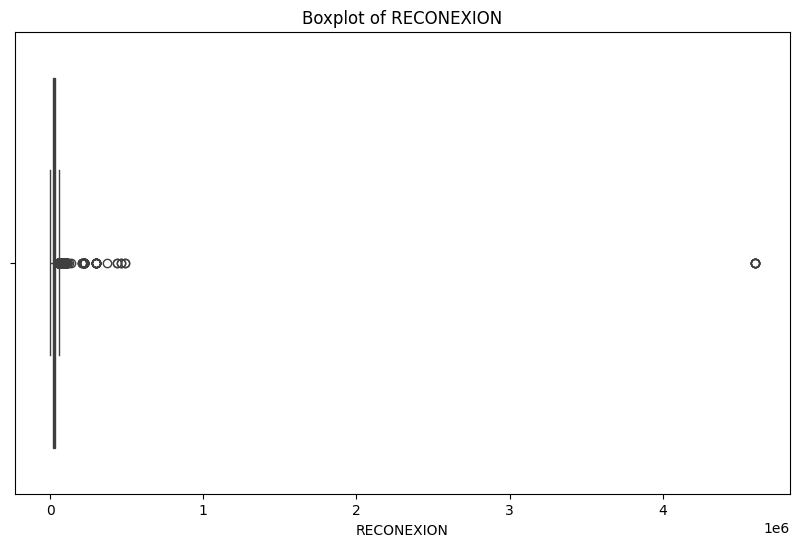

In [ ]:
# Crear un boxplot para visualizar la distribución de la columna 'RECONEXION' y detectar posibles valores atípicos
plt.figure(figsize=(10, 6)) # Definir el tamaño de la figura
sns.boxplot(x=df_gas_natural['RECONEXION']) # Crear el boxplot
plt.title('Boxplot of RECONEXION') # Establecer el título del gráfico
plt.xlabel('RECONEXION') # Establecer la etiqueta del eje x
plt.show() # Mostrar el gráfico

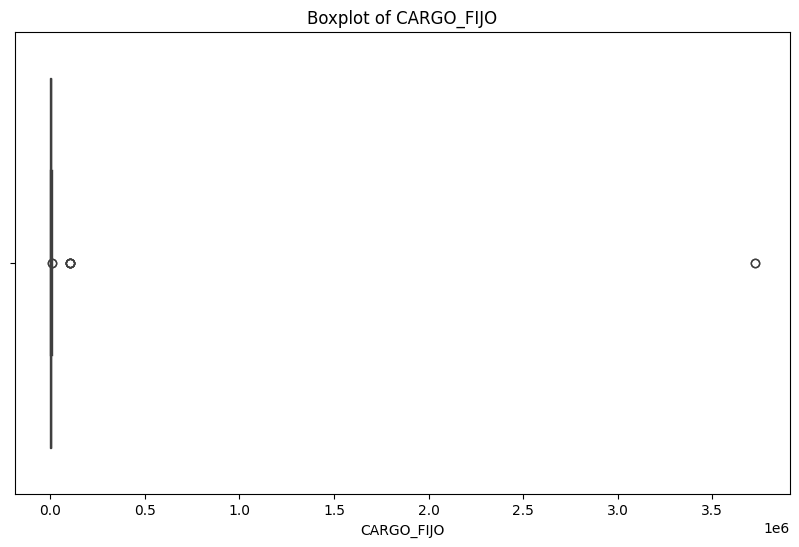

In [ ]:
# Crear un boxplot para visualizar la distribución de la columna 'CARGO_FIJO' y detectar posibles valores atípicos
plt.figure(figsize=(10, 6)) # Definir el tamaño de la figura
sns.boxplot(x=df_gas_natural['CARGO_FIJO']) # Crear el boxplot
plt.title('Boxplot of CARGO_FIJO') # Establecer el título del gráfico
plt.xlabel('CARGO_FIJO') # Establecer la etiqueta del eje x
plt.show() # Mostrar el gráfico

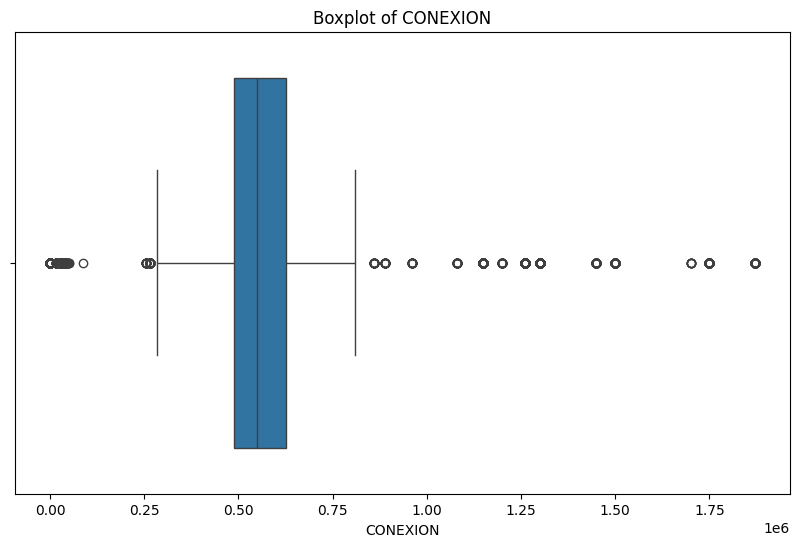

In [ ]:
# Crear un boxplot para visualizar la distribución de la columna 'CONEXION' y detectar posibles valores atípicos
plt.figure(figsize=(10, 6)) # Definir el tamaño de la figura
sns.boxplot(x=df_gas_natural['CONEXION']) # Crear el boxplot
plt.title('Boxplot of CONEXION') # Establecer el título del gráfico
plt.xlabel('CONEXION') # Establecer la etiqueta del eje x
plt.show() # Mostrar el gráfico

<Axes: xlabel='ANO', ylabel='CARGO_FIJO'>

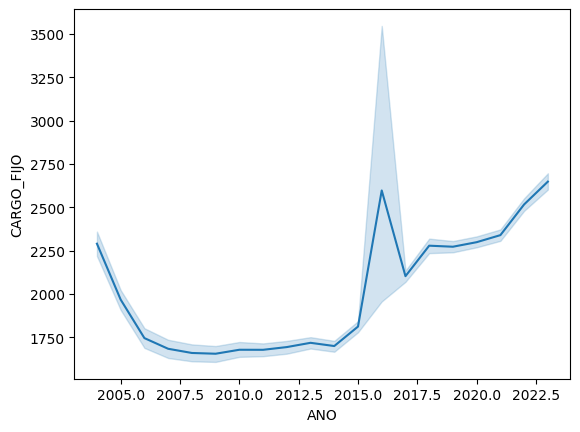

In [ ]:
# Crear un gráfico de línea para visualizar la tendencia de 'CARGO_FIJO' a lo largo de los años
sns.lineplot(df_gas_natural, x='ANO', y='CARGO_FIJO')

<Axes: xlabel='ANO', ylabel='RECONEXION'>

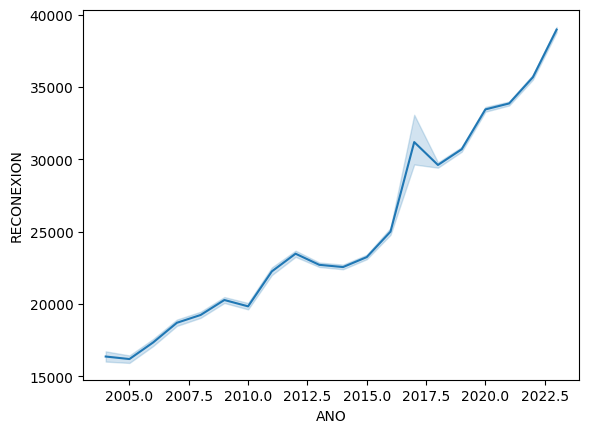

In [ ]:
# Crear un gráfico de línea para visualizar la tendencia de 'RECONEXION' a lo largo de los años
sns.lineplot(df_gas_natural, x='ANO', y='RECONEXION')

<Axes: xlabel='ANO', ylabel='REINSTALACION'>

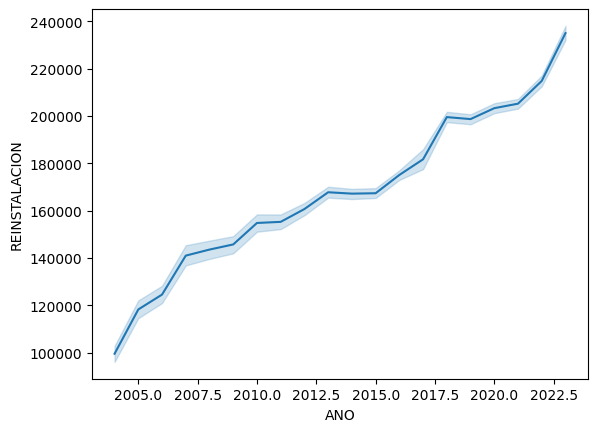

In [ ]:
# Crear un gráfico de línea para visualizar la tendencia de 'REINSTALACION' a lo largo de los años
sns.lineplot(df_gas_natural, x='ANO', y='REINSTALACION')

<Axes: xlabel='ANO', ylabel='CONEXION'>

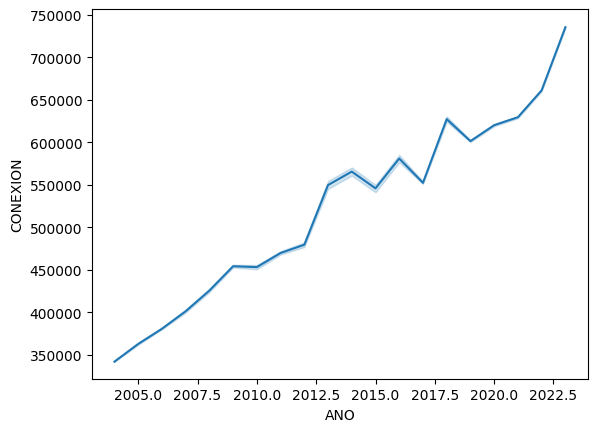

In [ ]:
# Crear un gráfico de línea para visualizar la tendencia de 'CONEXION' a lo largo de los años
sns.lineplot(df_gas_natural, x='ANO', y='CONEXION')

In [ ]:
# Crear una copia del DataFrame original para realizar modificaciones sin afectar los datos originales
df_gas_natural_copia1 = df_gas_natural.copy()

In [ ]:
# Calcular y mostrar la frecuencia de cada valor único en la columna 'RECONEXION'
print("\nValue counts for RECONEXION:")
display(df_gas_natural_copia1['RECONEXION'].value_counts())


Value counts for RECONEXION:


,count
RECONEXION,
20000.0,4607
35000.0,4561
30000.0,2232
0.0,2134
25000.0,2016
...,...
486756.0,1
372535.0,1
74081.0,1


In [ ]:
# Calcular y mostrar la frecuencia de cada valor único en la columna 'REINSTALACION'
print("\nValue counts for REINSTALACION:")
display(df_gas_natural_copia1['REINSTALACION'].value_counts())


Value counts for REINSTALACION:


,count
REINSTALACION,
219000.00,5755
330000.00,4616
0.00,3254
486936.00,2940
300000.00,2508
...,...
4234.15,1
1230.00,1
3637.54,1


In [ ]:
# Calcular y mostrar la frecuencia de cada valor único en la columna 'CARGO_FIJO'
print("\nValue counts for CARGO_FIJO:")
display(df_gas_natural_copia1['CARGO_FIJO'].value_counts())


Value counts for CARGO_FIJO:


,count
CARGO_FIJO,
0.00,58625
1476.00,500
1230.00,496
3200.00,230
3840.00,228
...,...
2228.77,1
3663.95,1
3673.49,1


In [ ]:
# Calcular y mostrar la frecuencia de cada valor único en la columna 'CONEXION'
print("Value counts for CONEXION:")
display(df_gas_natural_copia1['CONEXION'].value_counts())

Value counts for CONEXION:


,count
CONEXION,
540798.0,4435
1300000.0,3752
489125.0,2214
510780.0,2211
644881.0,1872
...,...
27256.0,1
28100.0,1
26000.0,1


In [ ]:
# Function to detect outliers using IQR
# Función para detectar valores atípicos usando el Rango Intercuartílico (IQR)
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25) # Calcular el primer cuartil (Q1)
    Q3 = df[column].quantile(0.75) # Calcular el tercer cuartil (Q3)
    IQR = Q3 - Q1 # Calcular el Rango Intercuartílico (IQR)
    lower_bound = Q1 - 1.5 * IQR # Calcular el límite inferior para detectar atípicos
    upper_bound = Q3 + 1.5 * IQR # Calcular el límite superior para detectar atípicos
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)] # Filtrar el DataFrame para obtener filas con valores atípicos
    return outliers # Devolver el DataFrame con los valores atípicos

# Detectar valores atípicos para cada columna especificada
outliers_conexion = detect_outliers_iqr(df_gas_natural, 'CONEXION')
outliers_cargo_fijo = detect_outliers_iqr(df_gas_natural, 'CARGO_FIJO')
outliers_reconexion = detect_outliers_iqr(df_gas_natural, 'RECONEXION')
outliers_reinstalacion = detect_outliers_iqr(df_gas_natural, 'REINSTALACION')

# Combinar los DataFrames de valores atípicos
# Usando concat con ignore_index=True para manejar posibles filas duplicadas si un valor atípico está presente en varias columnas
Data_Atipicos = pd.concat([outliers_conexion, outliers_cargo_fijo, outliers_reconexion]).drop_duplicates().reset_index(drop=True)

outliers_reconexion
#display(Data_Atipicos) # Mostrar las primeras filas del nuevo DataFrame

,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
24,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,SUBACHOQUE,8300454728,106,2225,1,752332.0,132985.22,62200.0,0.00,1035.94,2083.57
25,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,1,752332.0,132985.22,62200.0,0.00,760.56,1694.55
26,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,SUBACHOQUE,8300454728,106,2225,2,752332.0,132985.22,62200.0,0.00,1280.90,2083.57
27,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,2,752332.0,132985.22,62200.0,0.00,958.84,1694.55
28,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,SUBACHOQUE,8300454728,106,2225,5,752332.0,132985.22,62200.0,7351.00,2500.28,2500.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102809,2016,1,"GLOBAL, REDES Y OBRAS S.A.S. E.S.P.",PACHO,9009227600,140,32215,3,565388.0,30000.00,96000.0,3043.78,1749.36,0.00
109887,2015,5,ESPIGAS S.A. E.S.P.,MONIQUIRA,8040148859,18,3326,2,17000.0,3750.00,100000.0,1102.16,3750.00,1102.00
115659,2014,11,GAS NATURAL DEL CESAR S.A. E.S.P.,AGUACHICA - AGUSTIN CODAZZI - BECERRIL - CHIRI...,8040005513,21,525,2,34596.0,2900.00,107703.0,972.27,2900.00,773.59
115660,2014,11,GAS NATURAL DEL CESAR S.A. E.S.P.,AGUACHICA - AGUSTIN CODAZZI - BECERRIL - CHIRI...,8040005513,21,525,1,34596.0,2900.00,107703.0,972.27,2900.00,773.59


In [ ]:
# Crear DataFrame con los valores atípicos de la columna 'CONEXION'
data_atipicos_conexion = detect_outliers_iqr(df_gas_natural, 'CONEXION')
print(" - Data_Atipicos_CONEXION")
data_atipicos_conexion # Mostrar el DataFrame con los valores atípicos de 'CONEXION'

 - Data_Atipicos_CONEXION


,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
945,2023,9,GASES DEL CARIBE S.A. E.S.P.,BARANOA - BARRANQUILLA - CAMPO DE LA CRUZ - CA...,8901016912,31,484,2,35000.0,5166.00,219000.0,2817.00,2519.00,2498.00
946,2023,9,GASES DEL CARIBE S.A. E.S.P.,BARANOA - BARRANQUILLA - CAMPO DE LA CRUZ - CA...,8901016912,31,484,1,35000.0,5166.00,219000.0,2817.00,2519.00,2498.00
1780,2023,8,GAS NATURAL DEL ORIENTE S.A. E.S.P.,FLORIDABLANCA,8902059527,9,526,1,0.0,134665.64,60900.0,0.00,825.59,1882.68
3126,2023,7,INGENIERIA Y SERVICIOS S.A. E.S.P.,GUALMATAN,8040118001,548,22910,2,23500.0,3212.61,112300.0,7161.67,0.00,0.00
3143,2023,7,INGENIERIA Y SERVICIOS S.A. E.S.P.,GUALMATAN,8040118001,548,22910,3,23500.0,3212.61,112300.0,7161.67,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158283,2008,2,SERVICIOS PYBLICOS INGENIERYA Y GAS S.A. E.S.P.,CASABIANCA - FALAN - PALOCABILDO - VILLAHERMOSA,8090126994,64,20322,2,889000.0,122897.00,15000.0,0.00,303.00,505.00
158284,2008,2,SERVICIOS PYBLICOS INGENIERYA Y GAS S.A. E.S.P.,CASABIANCA - FALAN - PALOCABILDO - VILLAHERMOSA,8090126994,64,20322,3,961000.0,122897.00,15000.0,1899.00,505.00,505.00
158515,2008,1,SERVICIOS PYBLICOS INGENIERYA Y GAS S.A. E.S.P.,CASABIANCA - FALAN - PALOCABILDO - VILLAHERMOSA,8090126994,64,20322,1,859000.0,122897.00,15000.0,0.00,252.50,505.00
158516,2008,1,SERVICIOS PYBLICOS INGENIERYA Y GAS S.A. E.S.P.,CASABIANCA - FALAN - PALOCABILDO - VILLAHERMOSA,8090126994,64,20322,2,889000.0,122897.00,15000.0,0.00,303.00,505.00


In [ ]:
# Crear DataFrame con los valores atípicos de la columna 'RECONEXION'
data_atipicos_reconexion = detect_outliers_iqr(df_gas_natural, 'RECONEXION')
print(" - Data_Atipicos_RECONEXION")
data_atipicos_reconexion # Mostrar el DataFrame con los valores atípicos de 'RECONEXION'

 - Data_Atipicos_RECONEXION


,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
24,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,SUBACHOQUE,8300454728,106,2225,1,752332.0,132985.22,62200.0,0.00,1035.94,2083.57
25,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,1,752332.0,132985.22,62200.0,0.00,760.56,1694.55
26,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,SUBACHOQUE,8300454728,106,2225,2,752332.0,132985.22,62200.0,0.00,1280.90,2083.57
27,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,BELEN - BRICENO - CALDAS - CERINZA - CHIQUINQU...,8300454728,169,2225,2,752332.0,132985.22,62200.0,0.00,958.84,1694.55
28,2023,10,GAS NATURAL CUNDIBOYACENSE S.A. E.S.P.,SUBACHOQUE,8300454728,106,2225,5,752332.0,132985.22,62200.0,7351.00,2500.28,2500.28
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102809,2016,1,"GLOBAL, REDES Y OBRAS S.A.S. E.S.P.",PACHO,9009227600,140,32215,3,565388.0,30000.00,96000.0,3043.78,1749.36,0.00
109887,2015,5,ESPIGAS S.A. E.S.P.,MONIQUIRA,8040148859,18,3326,2,17000.0,3750.00,100000.0,1102.16,3750.00,1102.00
115659,2014,11,GAS NATURAL DEL CESAR S.A. E.S.P.,AGUACHICA - AGUSTIN CODAZZI - BECERRIL - CHIRI...,8040005513,21,525,2,34596.0,2900.00,107703.0,972.27,2900.00,773.59
115660,2014,11,GAS NATURAL DEL CESAR S.A. E.S.P.,AGUACHICA - AGUSTIN CODAZZI - BECERRIL - CHIRI...,8040005513,21,525,1,34596.0,2900.00,107703.0,972.27,2900.00,773.59


In [ ]:
# Crear DataFrame con los valores atípicos de la columna 'CARGO_FIJO'
data_atipicos_cargo_fijo = detect_outliers_iqr(df_gas_natural, 'CARGO_FIJO')
print(" - Data_Atipicos_CARGO_FIJO")
data_atipicos_cargo_fijo # Mostrar el DataFrame con los valores atípicos de 'CARGO_FIJO'

 - Data_Atipicos_CARGO_FIJO


,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
72155,2018,6,GAS NATURAL S.A E.S.P,"BogotA, Distrito Capital1 - SIBATE - SOACHA",8000078135,23,488,2,0.0,72083.00,46540.0,106561.00,2763.00,0.00
72156,2018,6,GAS NATURAL S.A E.S.P,"BogotA, Distrito Capital1 - SIBATE - SOACHA",8000078135,23,488,1,0.0,72083.00,46540.0,106561.00,2763.00,0.00
72160,2018,6,GAS NATURAL S.A E.S.P,"BogotA, Distrito Capital1 - SIBATE - SOACHA",8000078135,23,488,6,0.0,72083.00,46540.0,106561.00,2763.00,0.00
72164,2018,6,GAS NATURAL S.A E.S.P,"BogotA, Distrito Capital1 - SIBATE - SOACHA",8000078135,23,488,5,0.0,72083.00,46540.0,106561.00,2763.00,0.00
72168,2018,6,GAS NATURAL S.A E.S.P,"BogotA, Distrito Capital1 - SIBATE - SOACHA",8000078135,23,488,4,0.0,72083.00,46540.0,106561.00,2763.00,0.00
72172,2018,6,GAS NATURAL S.A E.S.P,"BogotA, Distrito Capital1 - SIBATE - SOACHA",8000078135,23,488,3,0.0,72083.00,46540.0,106561.00,2763.00,0.00
78304,2018,1,KEOPS & ASOCIADOS S.A.S E.S.P,PASUNCHA,9006532723,585,32213,2,30000.0,5347.45,80000.0,9731.61,9731.61,9731.61
78307,2018,1,KEOPS & ASOCIADOS S.A.S E.S.P,PASUNCHA,9006532723,585,32213,3,30000.0,5347.45,80000.0,8936.28,8936.28,8936.28
99821,2016,4,"GLOBAL, REDES Y OBRAS S.A.S. E.S.P.",PACHO,9009227600,140,32215,6,565388.0,30000.00,96000.0,3723696.00,2437.29,0.00
99822,2016,4,"GLOBAL, REDES Y OBRAS S.A.S. E.S.P.",PACHO,9009227600,140,32215,5,565388.0,30000.00,96000.0,3723696.00,2437.29,0.00


In [ ]:
# Crear DataFrame con los valores atípicos de la columna 'REINSTALACION'
data_atipicos_reinstalacion = detect_outliers_iqr(df_gas_natural, 'REINSTALACION')
print(" - Data_Atipicos_REINSTALACION")
data_atipicos_reinstalacion # Mostrar el DataFrame con los valores atípicos de 'REINSTALACION'

 - Data_Atipicos_REINSTALACION


,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
168,2023,10,GASES DEL CUSIANA S.A. E.S.P,TAURAMENA,8002186822,15,541,1,749397.0,581453.0,41111.0,0.0,820.35,1432.94
169,2023,10,GASES DEL CUSIANA S.A. E.S.P,AGUAZUL - MONTERREY - VILLANUEVA,8002186822,10,541,1,749397.0,581453.0,41111.0,0.0,882.74,1546.89
170,2023,10,GASES DEL CUSIANA S.A. E.S.P,AGUAZUL - MONTERREY - VILLANUEVA,8002186822,10,541,1,749397.0,581453.0,41111.0,0.0,882.74,1546.89
171,2023,10,GASES DEL CUSIANA S.A. E.S.P,AGUAZUL - MONTERREY - VILLANUEVA,8002186822,10,541,1,749397.0,581453.0,41111.0,0.0,882.74,1546.89
172,2023,10,GASES DEL CUSIANA S.A. E.S.P,AGUAZUL - MONTERREY - VILLANUEVA,8002186822,10,541,1,749397.0,581453.0,41111.0,0.0,618.69,743.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112981,2015,2,GASES DEL CUSIANA S.A. E.S.P,TAURAMENA,8002186822,15,541,3,510781.0,433993.0,25486.0,3723.0,612.00,612.00
112982,2015,2,GASES DEL CUSIANA S.A. E.S.P,AGUAZUL - MONTERREY - VILLANUEVA,8002186822,10,541,3,510781.0,433993.0,25486.0,3723.0,669.00,669.00
112983,2015,2,GASES DEL CUSIANA S.A. E.S.P,AGUAZUL - MONTERREY - VILLANUEVA,8002186822,10,541,3,510781.0,433993.0,25486.0,3723.0,669.00,669.00
112984,2015,2,GASES DEL CUSIANA S.A. E.S.P,AGUAZUL - MONTERREY - VILLANUEVA,8002186822,10,541,3,510781.0,433993.0,25486.0,3723.0,555.00,555.00


In [ ]:
# Crear una copia del DataFrame original
df_gas_natural_copia = df_gas_natural.copy()

# Mostrar información sobre la copia del DataFrame
df_gas_natural_copia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165360 entries, 0 to 165359
Data columns (total 14 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   ANO            165360 non-null  int64  
 1   MES            165360 non-null  int64  
 2   EMPRESA        165360 non-null  object 
 3   MUNICIPIOS     165360 non-null  object 
 4   NIT            165360 non-null  int64  
 5   ID MERCADO     165360 non-null  int64  
 6   ID_EMPRESA     165360 non-null  int64  
 7   ESTRATO        165360 non-null  int64  
 8   CONEXION       165360 non-null  float64
 9   REINSTALACION  165360 non-null  float64
 10  RECONEXION     165360 non-null  float64
 11  CARGO_FIJO     165360 non-null  float64
 12  RANGO_0        165360 non-null  float64
 13  RANGO_21       165360 non-null  float64
dtypes: float64(6), int64(6), object(2)
memory usage: 17.7+ MB


In [ ]:
# Localizar las filas donde el valor de 'CARGO_FIJO' es igual a 3723696.0
df_gas_natural_copia.loc[df_gas_natural_copia['CARGO_FIJO'] == 3723696.0]

,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
99821,2016,4,"GLOBAL, REDES Y OBRAS S.A.S. E.S.P.",PACHO,9009227600,140,32215,6,565388.0,30000.0,96000.0,3723696.0,2437.29,0.0
99822,2016,4,"GLOBAL, REDES Y OBRAS S.A.S. E.S.P.",PACHO,9009227600,140,32215,5,565388.0,30000.0,96000.0,3723696.0,2437.29,0.0


In [ ]:
# Obtener los índices de las filas donde 'CARGO_FIJO' es igual a 3723696.0 (valores atípicos)
indx_atipico_cargofijo = df_gas_natural_copia.loc[df_gas_natural_copia['CARGO_FIJO'] == 3723696.0].index
indx_atipico_cargofijo # Mostrar los índices encontrados

Index([99821, 99822], dtype='int64')

In [ ]:
# Reemplazar los valores atípicos en la columna 'CARGO_FIJO' con la mediana de la columna
df_gas_natural_copia.loc[indx_atipico_cargofijo, 'CARGO_FIJO'] = df_gas_natural_copia['CARGO_FIJO'].median()

In [ ]:
# Verificar el valor máximo en la columna 'CARGO_FIJO' después de reemplazar los atípicos
df_gas_natural_copia['CARGO_FIJO'].max()

106561.0

In [ ]:
# Obtener los índices de los valores atípicos detectados en las columnas 'CONEXION' y 'RECONEXION'
indx_atipicos_cone = data_atipicos_conexion.index
indx_atipicos_recone = data_atipicos_reconexion.index

##Transformamos atipicos en mediana

In [ ]:
# Reemplazar los valores atípicos en las columnas 'CONEXION' y 'RECONEXION' con la mediana de sus respectivas columnas
df_gas_natural_copia.loc[indx_atipicos_cone, 'CONEXION'] = df_gas_natural_copia['CONEXION'].median()
df_gas_natural_copia.loc[indx_atipicos_recone, 'RECONEXION'] = df_gas_natural_copia['RECONEXION'].median()

Al existir aprox 7000 datos atipicos, estos no llegan a representar el 5% del tamaño del dataset

🤖 Objetivo del análisis y preparación del modelo
Luego de realizar el análisis exploratorio del dataset, y teniendo en cuenta que nuestro propósito es crear un modelo inicial basado en LLMs para Inteligencia Artificial, tomamos la siguiente decisión:

🔹 Dado que no se encontraron valores nulos y únicamente se detectaron algunos valores atípicos, optamos por no aplicar tratamiento a dichos valores atípicos.
Esto se debe a que queremos trabajar con el dataset en su forma más original posible, con el fin de preservar sus características naturales durante el proceso de entrenamiento.

📈 El objetivo es utilizar esta información para:

Explorar posibles gráficas predictivas.

Entrenar un modelo que permita predecir el precio del gas natural en los próximos años.

## Prueba y Tantento de Modelos predictivos

## Regresion Multiple

In [ ]:
# Obtener el valor máximo de la columna 'CARGO_FIJO' en la copia del DataFrame
df_gas_natural_copia['CARGO_FIJO'].max()

106561.0

In [ ]:
# Filtrar el DataFrame para excluir filas con valores específicos en 'CARGO_FIJO' (posibles atípicos o errores)
df_gas_filtrado = df_gas_natural_copia[df_gas_natural_copia['CARGO_FIJO'] != -1009.71]
df_gas_filtrado = df_gas_filtrado[df_gas_filtrado['CARGO_FIJO'] != 106561.0]

In [ ]:
# Convertir los valores negativos en la columna 'CARGO_FIJO' a positivos
df_gas_filtrado.loc[df_gas_filtrado['CARGO_FIJO'] < 0, 'CARGO_FIJO'] = df_gas_filtrado.loc[df_gas_filtrado['CARGO_FIJO'] < 0, 'CARGO_FIJO'] * -1

In [ ]:
# Mostrar las filas donde el valor de 'CARGO_FIJO' es igual a 0
df_gas_filtrado.loc[df_gas_filtrado['CARGO_FIJO'] == 0, 'CARGO_FIJO']

,CARGO_FIJO
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
165137,0.0
165142,0.0
165143,0.0
165148,0.0


##Escalar columnas

In [ ]:
# Definir la lista de variables (columnas) que se utilizarán como características para el modelo
variables = ['CONEXION' , 'RECONEXION', 'ESTRATO', 'REINSTALACION', 'RANGO_0', 'RANGO_21']

In [ ]:
#se genera el escalamiento de las columnas para mejorar el aprenizaje
# Inicializar el escalador MinMaxScaler
scaler = MinMaxScaler()
# Escalar las columnas definidas en 'variables' al rango [0, 1]
df_gas_filtrado[variables] = scaler.fit_transform(df_gas_filtrado[variables])

In [ ]:
# Inicializar el escalador StandardScaler
scaler = StandardScaler()
# Escalar las columnas definidas en 'variables' para que tengan media 0 y varianza 1
df_gas_filtrado[variables] = scaler.fit_transform(df_gas_filtrado[variables])

In [ ]:
# Definir la variable objetivo (y) y las variables predictoras (X)
y = df_gas_filtrado['CARGO_FIJO']
X = df_gas_filtrado.drop(columns=['CARGO_FIJO', 'MUNICIPIOS', 'EMPRESA', 'NIT', 'ID MERCADO', 'ID_EMPRESA' ]) # Eliminar columnas no utilizadas como predictoras


# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42
)

#Verificamos las dimensiones de los conjuntos de datos
print("Dimensiones de X: ", X.shape)
print("Dimensiones de y: ", y.shape)

print(f"Tamaño de entrenamiento: x = {X_train.shape} muestras, y = {y_train.shape} ")
print(f"Tamaño de prueba: x = {X_test.shape} muestras, y = {y_test.shape}")

Dimensiones de X:  (165350, 8)
Dimensiones de y:  (165350,)
Tamaño de entrenamiento: x = (132280, 8) muestras, y = (132280,) 
Tamaño de prueba: x = (33070, 8) muestras, y = (33070,)


In [ ]:
print("--- Estadísticas Descriptivas de CARGO_FIJO ---")
print(y.describe()) # Mostrar estadísticas descriptivas de la variable objetivo

print(f"\nDesviación Estándar (std): {y.std()}") # Calcular y mostrar la desviación estándar
print(f"Rango (Max - Min): {y.max() - y.min()}") # Calcular y mostrar el rango

--- Estadísticas Descriptivas de CARGO_FIJO ---
count    165350.000000
mean       2080.378713
std        1827.386813
min           0.000000
25%           0.000000
50%        2266.600000
75%        3382.187500
max        9731.610000
Name: CARGO_FIJO, dtype: float64

Desviación Estándar (std): 1827.3868131987354
Rango (Max - Min): 9731.61


In [ ]:
# Encontrar y mostrar el valor mínimo en la columna 'ESTRATO' del DataFrame original
df_gas_natural_copia['ESTRATO'].min()

1

In [ ]:
# Encontrar y mostrar el valor mínimo en la columna 'ESTRATO' del DataFrame filtrado
df_gas_filtrado['ESTRATO'].min()

-1.3945710754108678

In [ ]:
# Inicializar y entrenar el modelo de regresión lineal múltiple
modelo_multi = LinearRegression()
modelo_multi.fit(X_train, y_train) # Entrenar el modelo con los datos de entrenamiento

LinearRegression()

In [ ]:
# Realizar predicciones sobre el conjunto de prueba utilizando el modelo entrenado
y_pred_multi = modelo_multi.predict(X_test)
print(y_pred_multi) # Mostrar las predicciones

[  17.72716147 1472.027293   -232.35001392 ... 1541.47197717  258.65362286
 2396.31740191]


In [ ]:
# Mostrar el tipo de dato de las predicciones
type(y_pred_multi)
# Calcular y mostrar el valor máximo de las predicciones
np.max(y_pred_multi)

np.float64(16163.605198130957)

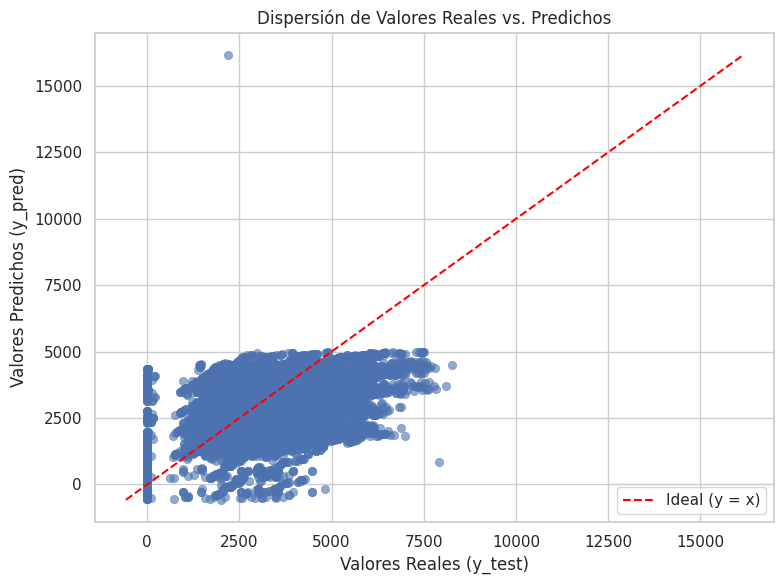

In [ ]:
# Crear un gráfico de dispersión para visualizar la relación entre los valores reales (y_test) y los valores predichos (y_pred_multi)
#plt.ylim(0,7000) # Opcional: limitar el rango del eje y para una mejor visualización si hay muchos valores atípicos en las predicciones
# Estilo más limpio
sns.set(style="whitegrid")

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_multi, alpha=0.6, edgecolor=None)

# Agregar línea de referencia y = x
min_val = min(min(y_test), min(y_pred_multi))
max_val = max(max(y_test), max(y_pred_multi))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal (y = x)')

# Etiquetas y título
plt.xlabel("Valores Reales (y_test)")
plt.ylabel("Valores Predichos (y_pred)")
plt.title("Dispersión de Valores Reales vs. Predichos")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calcular métricas de evaluación para el modelo de regresión
mse = mean_squared_error(y_test, y_pred_multi) # Error Cuadrático Medio
mae = mean_absolute_error(y_test, y_pred_multi) # Error Absoluto Medio
r2 = r2_score(y_test, y_pred_multi) # Coeficiente de Determinación (R2)

# Mostrar las métricas de evaluación
print(f"MSE ( Error Cuadratico Medio: {mse:.2f})")
print(f"MAE ( Error Absoluto Medio: {mae:.2f})")
print(f"R2 (Coef. de Determinación): {r2:.2f}")

MSE ( Error Cuadratico Medio: 1433822.81)
MAE ( Error Absoluto Medio: 931.88)
R2 (Coef. de Determinación): 0.57


Modelo de regresion multiple con conexion


In [ ]:
# Create a new DataFrame
df_conexion_por_ano = df_gas_natural[['ANO', 'CONEXION', 'ESTRATO','MUNICIPIOS','MES','EMPRESA']]

# Display the new DataFrame
display(df_conexion_por_ano)

,ANO,CONEXION,ESTRATO,MUNICIPIOS,MES,EMPRESA
0,2023,718800.0,1,BALBOA - DOSQUEBRADAS - LA CELIA - LA VIRGINIA...,10,EFIGAS GAS NATURAL S.A. E.S.P.
1,2023,718800.0,1,CHINCHINA - MANIZALES - NEIRA - PALESTINA - VI...,10,EFIGAS GAS NATURAL S.A. E.S.P.
2,2023,718800.0,1,AGUADAS - ANSERMA - ARANZAZU - BELALCAZAR - PA...,10,EFIGAS GAS NATURAL S.A. E.S.P.
3,2023,718800.0,1,ARMENIA - CALARCA - CIRCASIA - FILANDIA - LA T...,10,EFIGAS GAS NATURAL S.A. E.S.P.
4,2023,718800.0,2,ARMENIA - CALARCA - CIRCASIA - FILANDIA - LA T...,10,EFIGAS GAS NATURAL S.A. E.S.P.
...,...,...,...,...,...,...
165355,2004,340046.0,6,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P
165356,2004,340046.0,2,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P
165357,2004,340046.0,1,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P
165358,2004,340046.0,4,CAUCASIA - ARJONA - CARTAGENA DE INDIAS - CICU...,1,SURTIDORA DE GAS DEL CARIBE S.A. E.S.P


In [ ]:
df_gas_natural_copia_conexion = detect_outliers_iqr(df_gas_natural_copia, 'CONEXION')
print(" - Data_Atipicos_CARGO_FIJO")
df_gas_natural_copia_conexion

 - Data_Atipicos_CARGO_FIJO


,ANO,MES,EMPRESA,MUNICIPIOS,NIT,ID MERCADO,ID_EMPRESA,ESTRATO,CONEXION,REINSTALACION,RECONEXION,CARGO_FIJO,RANGO_0,RANGO_21
91231,2016,12,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,1,282500.0,65735.0,23923.0,0.00,961.86,1770.43
91252,2016,12,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,2,282500.0,65735.0,23923.0,0.00,1154.35,1770.43
91278,2016,12,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,6,282500.0,65735.0,23923.0,4018.06,2124.52,2124.52
91279,2016,12,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,5,282500.0,65735.0,23923.0,4018.06,2124.52,2124.52
91280,2016,12,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,4,282500.0,65735.0,23923.0,3348.38,1770.43,1770.43
91281,2016,12,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,3,282500.0,65735.0,23923.0,3348.38,1770.43,1770.43
92170,2016,11,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,1,282500.0,65735.0,23923.0,0.00,962.49,1715.58
92191,2016,11,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,2,282500.0,65735.0,23923.0,0.00,1155.10,1715.58
92216,2016,11,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,3,282500.0,65735.0,23923.0,3360.56,1715.58,1715.58
92217,2016,11,EMPRESAS PUBLICAS DE MEDELLIN E.S.P.,ITUANGO - LIBORINA - OLAYA - SABANALARGA - SAN...,8909049961,218,564,6,282500.0,65735.0,23923.0,4032.67,2058.70,2058.70


In [ ]:
# Definir la variable objetivo (y) y las variables predictoras (X)
y = df_gas_filtrado['CONEXION']
X = df_gas_filtrado.drop(columns=['CONEXION', 'MUNICIPIOS', 'EMPRESA', 'NIT', 'ID MERCADO', 'ID_EMPRESA' ]) # Eliminar columnas no utilizadas como predictoras


# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=42
)

#Verificamos las dimensiones de los conjuntos de datos
print("Dimensiones de X: ", X.shape)
print("Dimensiones de y: ", y.shape)

print(f"Tamaño de entrenamiento: x = {X_train.shape} muestras, y = {y_train.shape} ")
print(f"Tamaño de prueba: x = {X_test.shape} muestras, y = {y_test.shape}")

Dimensiones de X:  (165350, 8)
Dimensiones de y:  (165350,)
Tamaño de entrenamiento: x = (132280, 8) muestras, y = (132280,) 
Tamaño de prueba: x = (33070, 8) muestras, y = (33070,)


In [ ]:
print("--- Estadísticas Descriptivas de Conexion ---")
print(y.describe()) # Mostrar estadísticas descriptivas de la variable objetivo

print(f"\nDesviación Estándar (std): {y.std()}") # Calcular y mostrar la desviación estándar
print(f"Rango (Max - Min): {y.max() - y.min()}") # Calcular y mostrar el rango

--- Estadísticas Descriptivas de Conexion ---
count    1.653500e+05
mean    -6.022962e-16
std      1.000003e+00
min     -2.876715e+00
25%     -6.956629e-01
50%     -5.052781e-02
75%      6.996342e-01
max      2.686102e+00
Name: CONEXION, dtype: float64

Desviación Estándar (std): 1.0000030239024051
Rango (Max - Min): 5.562817024861021


In [ ]:
# Encontrar y mostrar el valor mínimo en la columna 'ESTRATO' del DataFrame original
df_gas_natural_copia['ESTRATO'].min()

1

In [ ]:
# Encontrar y mostrar el valor mínimo en la columna 'ESTRATO' del DataFrame filtrado
df_gas_filtrado['ESTRATO'].min()

-1.3945710754108678

In [ ]:
# Inicializar y entrenar el modelo de regresión lineal múltiple
modelo_multi = LinearRegression()
modelo_multi.fit(X_train, y_train) # Entrenar el modelo con los datos de entrenamiento

LinearRegression()

In [ ]:
# Realizar predicciones sobre el conjunto de prueba utilizando el modelo entrenado
y_pred_multi = modelo_multi.predict(X_test)
print(y_pred_multi) # Mostrar las predicciones

[-0.10066021 -0.88116486 -1.61061902 ... -0.51155969 -0.63976254
  0.72421009]


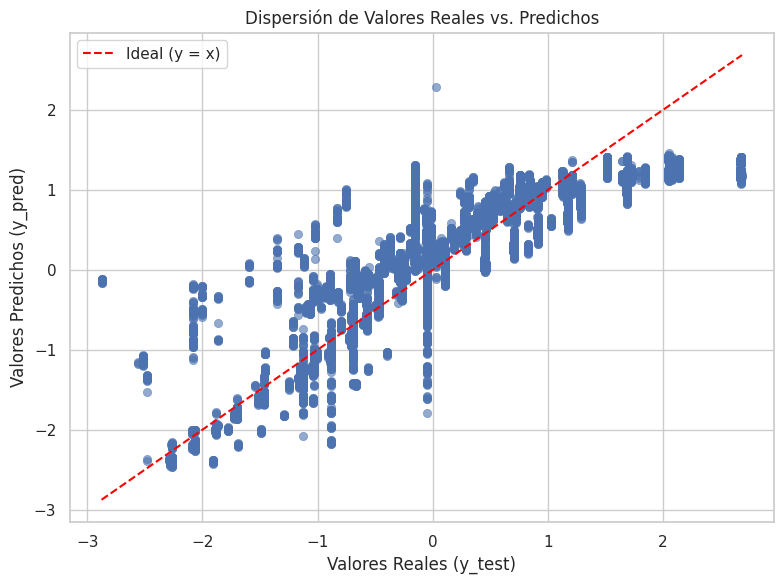

In [ ]:
# Crear un gráfico de dispersión para visualizar la relación entre los valores reales (y_test) y los valores predichos (y_pred_multi)
#plt.ylim(0,7000) # Opcional: limitar el rango del eje y para una mejor visualización si hay muchos valores atípicos en las predicciones
# Estilo más limpio
sns.set(style="whitegrid")

# Crear el gráfico
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred_multi, alpha=0.6, edgecolor=None)

# Agregar línea de referencia y = x
min_val = min(min(y_test), min(y_pred_multi))
max_val = max(max(y_test), max(y_pred_multi))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Ideal (y = x)')

# Etiquetas y título
plt.xlabel("Valores Reales (y_test)")
plt.ylabel("Valores Predichos (y_pred)")
plt.title("Dispersión de Valores Reales vs. Predichos")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Calcular métricas de evaluación para el modelo de regresión
mse = mean_squared_error(y_test, y_pred_multi) # Error Cuadrático Medio
mae = mean_absolute_error(y_test, y_pred_multi) # Error Absoluto Medio
r2 = r2_score(y_test, y_pred_multi) # Coeficiente de Determinación (R2)

# Mostrar las métricas de evaluación
print(f"MSE ( Error Cuadratico Medio: {mse:.2f})")
print(f"MAE ( Error Absoluto Medio: {mae:.2f})")
print(f"R2 (Coef. de Determinación): {r2:.2f}")

MSE ( Error Cuadratico Medio: 0.22)
MAE ( Error Absoluto Medio: 0.35)
R2 (Coef. de Determinación): 0.77


In [ ]:
# Definir la variable objetivo (y) para el modelo ElasticNet.
y_conexion = df_gas_filtrado['CONEXION']
# Definir las variables predictoras (X) para el modelo ElasticNet.
X_conexion = df_gas_filtrado.drop(columns=['CONEXION', 'CARGO_FIJO', 'MUNICIPIOS', 'EMPRESA', 'NIT', 'ID MERCADO', 'ID_EMPRESA' ]) # Excluir la variable objetivo y columnas no relevantes

# Dividir los datos de las variables predictoras (X_conexion) y la variable objetivo (y_conexion) en conjuntos de entrenamiento y prueba.
# Se utiliza train_test_split para esta división aleatoria.
# train_size=0.8 indica que el 80% de los datos se utilizarán para entrenar el modelo.
# random_state=42 asegura que la división de los datos sea la misma cada vez que se ejecute el código, garantizando la reproducibilidad de los resultados.
X_train_conexion, X_test_conexion, y_train_conexion, y_test_conexion = train_test_split(X_conexion, y_conexion, train_size=0.8, random_state=42)

elasticnet_model = ElasticNet(random_state=42)
# Entrenar el modelo ElasticNet utilizando los datos de entrenamiento.
# El método fit ajusta los coeficientes del modelo para minimizar la función de costo, que incluye los errores de predicción y los términos de regularización.
elasticnet_model.fit(X_train_conexion, y_train_conexion)

# Realizar predicciones sobre el conjunto de prueba utilizando el modelo ElasticNet entrenado.
# El método predict toma las variables predictoras del conjunto de prueba (X_test_conexion) y devuelve los valores predichos para la variable objetivo (CONEXION).
y_pred_conexion = elasticnet_model.predict(X_test_conexion)

# Evaluar el rendimiento del modelo ElasticNet comparando las predicciones (y_pred_conexion) con los valores reales (y_test_conexion).
# Calcular el Error Cuadrático Medio (MSE).
mse_conexion = mean_squared_error(y_test_conexion, y_pred_conexion)
# Calcular el Error Absoluto Medio (MAE).
mae_conexion = mean_absolute_error(y_test_conexion, y_pred_conexion)
# Calcular el Coeficiente de Determinación (R2).
r2_conexion = r2_score(y_test_conexion, y_pred_conexion)

print(f"Rendimiento del Modelo ElasticNet para CONEXION:")
print(f"MSE (Error Cuadrático Medio): {mse_conexion:.2f}")
print(f"MAE (Error Absoluto Medio): {mae_conexion:.2f}")
print(f"R2 (Coeficiente de Determinación): {r2_conexion:.2f}")

Rendimiento del Modelo ElasticNet para CONEXION:
MSE (Error Cuadrático Medio): 0.25
MAE (Error Absoluto Medio): 0.35
R2 (Coeficiente de Determinación): 0.75


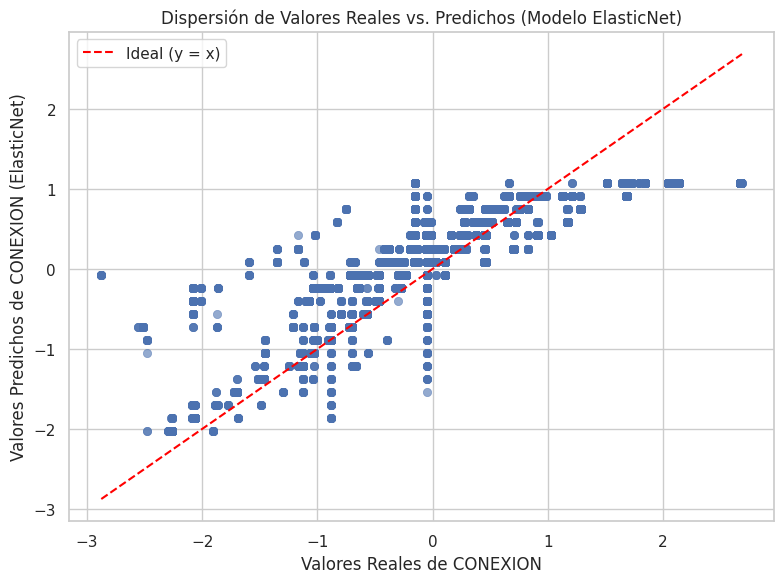

In [ ]:
sns.set(style="whitegrid")

# Crear una figura con un tamaño específico para el gráfico para una mejor visualización.
plt.figure(figsize=(8, 6))
# Crear el gráfico de dispersión con los valores reales en el eje x y los predichos en el eje y.
# Los puntos representan cada observación en el conjunto de prueba.
# alpha=0.6 proporciona transparencia a los puntos, lo que ayuda a ver la densidad donde hay muchos puntos superpuestos.
# edgecolor=None elimina el borde de los puntos para una apariencia más limpia.
sns.scatterplot(x=y_test_conexion, y=y_pred_conexion, alpha=0.6, edgecolor=None)

# Agregar una línea de referencia donde y = x (línea ideal).
# Esta línea diagonal representa dónde estarían los puntos si las predicciones fueran perfectas (predicho = real).
# Ayuda a visualizar qué tan cerca están las predicciones de los valores reales.
# Calcular los valores mínimo y máximo de ambos conjuntos de datos (reales y predichos) para asegurar que la línea cubra todo el rango relevante.
min_val_conexion = min(min(y_test_conexion), min(y_pred_conexion))
max_val_conexion = max(max(y_test_conexion), max(y_pred_conexion))
# Trazar la línea diagonal desde (min_val, min_val) hasta (max_val, max_val).
# color='red' establece el color de la línea a rojo.
# linestyle='--' hace que la línea sea discontinua.
# label='Ideal (y = x)' proporciona una etiqueta para la leyenda.
plt.plot([min_val_conexion, max_val_conexion], [min_val_conexion, max_val_conexion], color='red', linestyle='--', label='Ideal (y = x)')

# Establecer las etiquetas de los ejes y el título del gráfico.
plt.xlabel("Valores Reales de CONEXION")
plt.ylabel("Valores Predichos de CONEXION (ElasticNet)")
plt.title("Dispersión de Valores Reales vs. Predichos (Modelo ElasticNet)")
# Mostrar la leyenda en el gráfico, que incluye la etiqueta de la línea ideal.
plt.legend()
# Ajustar automáticamente los parámetros de la subtrama para dar un diseño ajustado.
plt.tight_layout()
# Mostrar el gráfico.
plt.show()

In [ ]:
# Definir la variable objetivo (y) para el modelo ElasticNet.
y_conexion = df_gas_filtrado['CONEXION']
# Definir las variables predictoras (X) para el modelo ElasticNet.
X_conexion = df_gas_filtrado.drop(columns=['CONEXION', 'CARGO_FIJO', 'MUNICIPIOS', 'EMPRESA', 'NIT', 'ID MERCADO', 'ID_EMPRESA' ]) # Excluir la variable objetivo y columnas no relevantes

# Dividir los datos de las variables predictoras (X_conexion) y la variable objetivo (y_conexion) en conjuntos de entrenamiento y prueba.
# Se utiliza train_test_split para esta división aleatoria.
# train_size=0.8 indica que el 80% de los datos se utilizarán para entrenar el modelo.
# random_state=42 asegura que la división de los datos sea la misma cada vez que se ejecute el código, garantizando la reproducibilidad de los resultados.
X_train_conexion, X_test_conexion, y_train_conexion, y_test_conexion = train_test_split(X_conexion, y_conexion, train_size=0.8, random_state=42)

elasticnet_model = ElasticNet(random_state=42)
# Entrenar el modelo ElasticNet utilizando los datos de entrenamiento.
# El método fit ajusta los coeficientes del modelo para minimizar la función de costo, que incluye los errores de predicción y los términos de regularización.
elasticnet_model.fit(X_train_conexion, y_train_conexion)

# Realizar predicciones sobre el conjunto de prueba utilizando el modelo ElasticNet entrenado.
# El método predict toma las variables predictoras del conjunto de prueba (X_test_conexion) y devuelve los valores predichos para la variable objetivo (CONEXION).
y_pred_conexion = elasticnet_model.predict(X_test_conexion)

# Evaluar el rendimiento del modelo ElasticNet comparando las predicciones (y_pred_conexion) con los valores reales (y_test_conexion).
# Calcular el Error Cuadrático Medio (MSE).
mse_conexion = mean_squared_error(y_test_conexion, y_pred_conexion)
# Calcular el Error Absoluto Medio (MAE).
mae_conexion = mean_absolute_error(y_test_conexion, y_pred_conexion)
# Calcular el Coeficiente de Determinación (R2).
r2_conexion = r2_score(y_test_conexion, y_pred_conexion)

# Imprimir las métricas de evaluación calculadas para el modelo ElasticNet aplicado a la predicción de CONEXION.
# Los valores se formatean a dos decimales para facilitar la lectura.
print(f"Rendimiento del Modelo ElasticNet para CONEXION:")
print(f"MSE (Error Cuadrático Medio): {mse_conexion:.2f}")
print(f"MAE (Error Absoluto Medio): {mae_conexion:.2f}")
print(f"R2 (Coeficiente de Determinación): {r2_conexion:.2f}")

Rendimiento del Modelo ElasticNet para CONEXION:
MSE (Error Cuadrático Medio): 0.25
MAE (Error Absoluto Medio): 0.35
R2 (Coeficiente de Determinación): 0.75


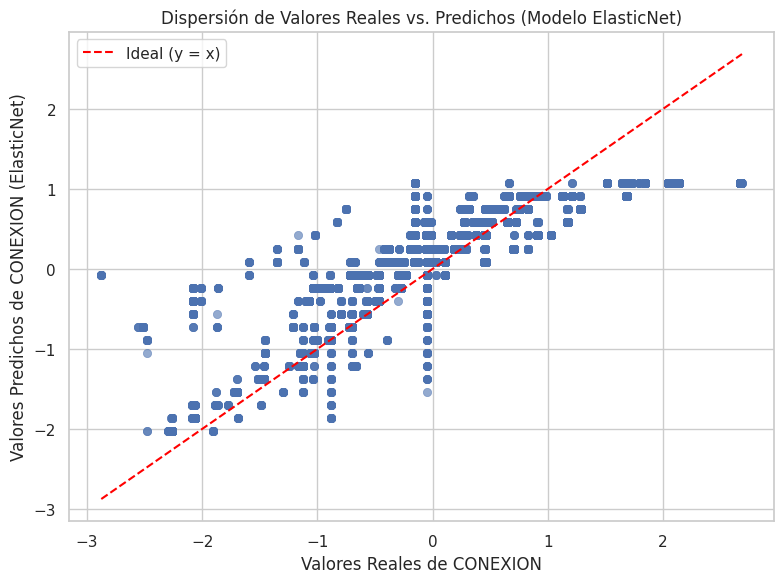

In [ ]:
sns.set(style="whitegrid")

# Crear una figura con un tamaño específico para el gráfico para una mejor visualización.
plt.figure(figsize=(8, 6))
# Crear el gráfico de dispersión con los valores reales en el eje x y los predichos en el eje y.
# Los puntos representan cada observación en el conjunto de prueba.
# alpha=0.6 proporciona transparencia a los puntos, lo que ayuda a ver la densidad donde hay muchos puntos superpuestos.
# edgecolor=None elimina el borde de los puntos para una apariencia más limpia.
sns.scatterplot(x=y_test_conexion, y=y_pred_conexion, alpha=0.6, edgecolor=None)

# Agregar una línea de referencia donde y = x (línea ideal).
# Esta línea diagonal representa dónde estarían los puntos si las predicciones fueran perfectas (predicho = real).
# Ayuda a visualizar qué tan cerca están las predicciones de los valores reales.
# Calcular los valores mínimo y máximo de ambos conjuntos de datos (reales y predichos) para asegurar que la línea cubra todo el rango relevante.
min_val_conexion = min(min(y_test_conexion), min(y_pred_conexion))
max_val_conexion = max(max(y_test_conexion), max(y_pred_conexion))
# Trazar la línea diagonal desde (min_val, min_val) hasta (max_val, max_val).
# color='red' establece el color de la línea a rojo.
# linestyle='--' hace que la línea sea discontinua.
# label='Ideal (y = x)' proporciona una etiqueta para la leyenda.
plt.plot([min_val_conexion, max_val_conexion], [min_val_conexion, max_val_conexion], color='red', linestyle='--', label='Ideal (y = x)')

# Establecer las etiquetas de los ejes y el título del gráfico.
plt.xlabel("Valores Reales de CONEXION")
plt.ylabel("Valores Predichos de CONEXION (ElasticNet)")
plt.title("Dispersión de Valores Reales vs. Predichos (Modelo ElasticNet)")
# Mostrar la leyenda en el gráfico, que incluye la etiqueta de la línea ideal.
plt.legend()
# Ajustar automáticamente los parámetros de la subtrama para dar un diseño ajustado.
plt.tight_layout()
# Mostrar el gráfico.
plt.show()